In [31]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
def load_root_files(dir_list, tags, tree, cut, variables):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            path = os.path.join(d, f"weighted_{tag}.BCS.root")
            if os.path.exists(path):
                file_map[tag].append(path)

    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        # df["ds_weight"] = 1/4
        
        # ccbar 분리
        if tag == "ccbar":
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID==etapip_Eta_genMotherID) & (Pip_genMotherPDG==431 | Pip_genMotherPDG==-431)").copy()
            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431) | (Pip_genMotherPDG == -431))").copy()
            df_bkg = df.query("(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )").copy()

            df_bkg["ds_weight"] = df_bkg["ds_weight"]
            df_bkg.drop(columns="Dp_isSignal", inplace=True)

            df_bkg2 = df.query("(Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 321) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -321) ) )").copy()
            df_bkg2["ds_weight"] = df_bkg2["ds_weight"]
            df_bkg2.drop(columns="Dp_isSignal", inplace=True)           

            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_bkg"] = df_bkg.query(cut)
            dataframes["ccbar_bkg2"] = df_bkg2.query(cut)
        else:
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes

In [33]:
def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 60)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    # data_hist, _ = np.histogram(data_df[var], bins=xbins)
    # ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.3f} GeV/$c^2$)")
    ax.legend(loc="upper left", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()

In [34]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg2', 'ccbar_bkg', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$', r'$D^+_s$ signal',  r'$D^+$ signal'
]


In [37]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/gg"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_gg_K"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight"]
var = "Dp_M"
bins = (1.75,2.045)
xlabel = r"$M(\eta_{\gamma\gamma}K^+)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_stack_weighted_new_Ds_correct.png")
# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v3"
mc_dirs = [f"{mc_base}/15rd_eta_{e}/{tree}/min_unc_search/0.91/weighted" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables)


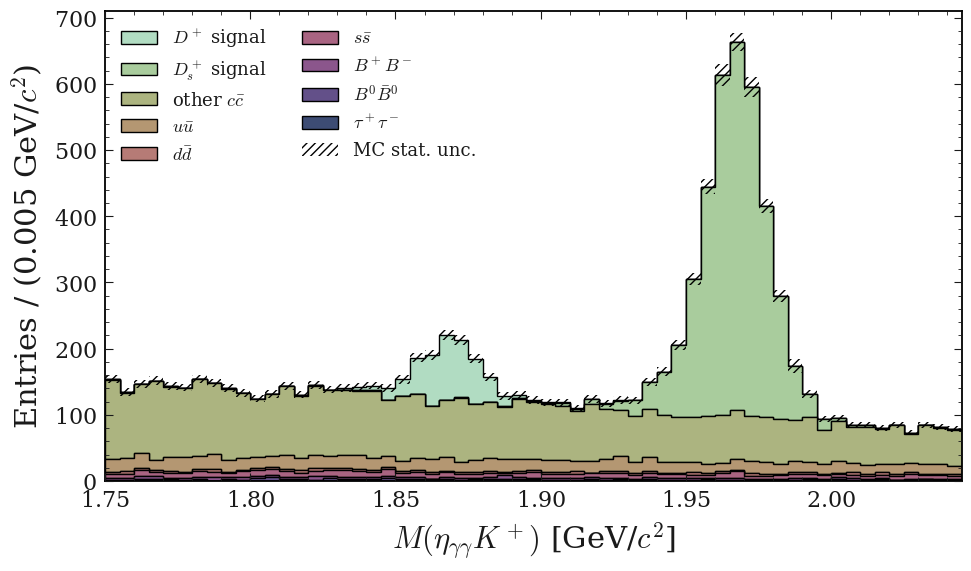

In [38]:
plot_stack_with_data(mc_data, tag_order, labels, None, var, bins, xlabel, output)

In [19]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/gg"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_gg_K"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight"]
var = "Dp_M"
bins = (1.75,2.045)
xlabel = r"$M(\eta_{\gamma\gamma}K^+)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_stack_weighted_new_Ds_correct.png")
output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v3"
mc_dirs = [f"{mc_base}/15rd_eta_{e}/{tree}/min_unc_search/0.91/weighted" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables)


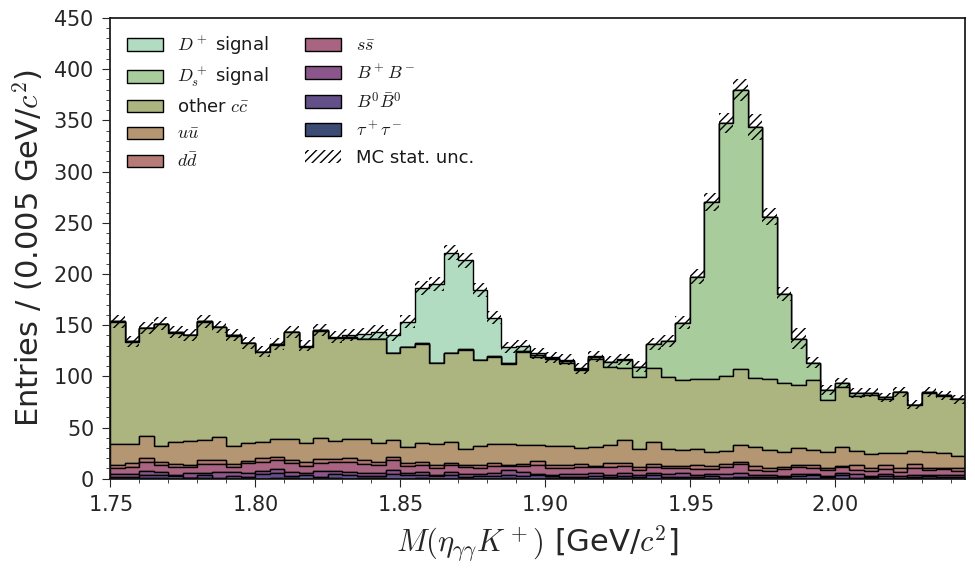

In [20]:
plot_stack_with_data(mc_data, tag_order, labels, None, var, bins, xlabel, output)

In [2]:
plot_directory = "/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/gg"
# plot_directory = os.path.dirname(file_path)
if not os.path.exists(plot_directory):
    os.makedirs(plot_directory)

In [3]:
tree = 'etapip_gg_K'
base_cut = 'Dp_M>0'
# output_dir = os.path.join("MC15rd", f"histograms_{tree}")
# os.makedirs(output_dir, exist_ok=True)

In [4]:
base_path="/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v2"
dir_list = [
    f"{base_path}/15rd_eta_e7_18_4S_v3/{tree}/min_unc_search/0.92/weighted",
    f"{base_path}/15rd_eta_e20_b26_v1/{tree}/min_unc_search/0.92/weighted",
    f"{base_path}/15rd_eta_e20_e26_4S_v2/{tree}/min_unc_search/0.92/weighted",
    f"{base_path}/15rd_eta_e21_5S_scan_v1/{tree}/min_unc_search/0.92/weighted",
    f"{base_path}/15rd_eta_mori_off_v1/{tree}/min_unc_search/0.92/weighted",
]

In [5]:
# Sample tags
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']

# Aggregate all ROOT files by tag
file_map = {tag: [] for tag in tags}
for tag in tags:
    for d in dir_list:
        path = os.path.join(d, f"weighted_{tag}.BCS.root")
        if os.path.exists(path):
            file_map[tag].append(path)

In [6]:
file_map['ccbar']

['/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v2/15rd_eta_e7_18_4S_v3/etapip_gg_K/min_unc_search/0.92/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v2/15rd_eta_e20_b26_v1/etapip_gg_K/min_unc_search/0.92/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v2/15rd_eta_e20_e26_4S_v2/etapip_gg_K/min_unc_search/0.92/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v2/15rd_eta_e21_5S_scan_v1/etapip_gg_K/min_unc_search/0.92/weighted/weighted_ccbar.BCS.root',
 '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15r

In [7]:
num_files = 0
for tag in tags:
    num_files += len(file_map[tag]) 
print(num_files)

33


In [8]:
# Load one file to get variable list
chain = ROOT.TChain(tree)
for path in file_map['ccbar']:
    chain.Add(path)
variables = [b.GetName() for b in chain.GetListOfBranches()]
variables = ['Dp_M']

Error in <TList::Clear>: A list is accessing an object (0x5638b179df50) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5638b1798ed0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5638b1799240) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5638b17995b0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5638b1799a20) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5638b1799ec0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5638b179a290) already deleted (list name = TList)


In [9]:
dataframes = {}
for tag in tags:
    dfs = [get_pd(file=fp, tree=tree, base_filter=base_cut, variables=variables) for fp in file_map[tag]]
    dataframes[tag] = pd.concat(dfs, ignore_index=True)

In [10]:
cut1 = "Dp_M>0"

In [11]:
for tag in tags:
    dataframes[tag] =dataframes[tag].query(cut1)

In [12]:
scale = 1
# luminosity=r"$1000\; \mathrm{fb}^{-1}$"
luminosity=""

In [13]:
def wrap_draw(var=str(),data=dataframes,scale=scale,xrange=tuple(),nbins=int(),xlabel=str(), luminosity=luminosity,img_path="",force_range=tuple(),legend_loc="" ):
    data = [dataframes[tag][var] for tag in tag_order]
    
    # data  = [pd_taupair[var], pd_mixed[var], pd_charged[var],pd_ssbar[var], pd_ddbar[var],pd_uubar[var], pd_ccbar[var]]  
    # labels = [   r'$\tau\bar{\tau}$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$'  ,r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
    MC_stack_plot(data, var, scale, xrange, nbins, xlabel=xlabel, labels=labels,title="", unit="[GeV/c^2]",luminosity=luminosity,force_range=force_range,save_repo=img_path, legend_loc=legend_loc)
    plt.tight_layout()

In [14]:
295/5

59.0

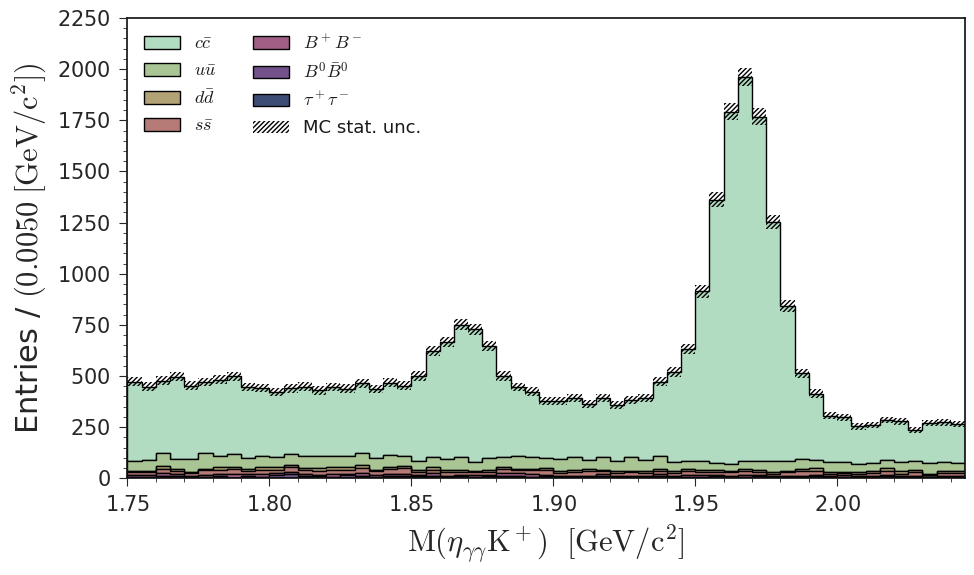

In [15]:
var = 'Dp_M'
# data  = [pd_taupair[var], pd_mixed[var], pd_charged[var],pd_ssbar[var], pd_ddbar[var],pd_uubar[var], pd_ccbar[var]]  

xrange = (1.75,2.045)

nbins = 59
xlabel = "$\mathrm{M(\eta_{\gamma\gamma}K^+)}$"

# img_path = plot_directory + "/MC15ri_Dpetapip_gg_pre_sel_DpM_step0.png"
# img_path = plot_directory + "/MC15ri_Dpetapip_gg_tight_selv1_DpM.png"
# img_path = plot_directory + "/MC15ri_Dpetapip_gg_loose_v0_trainv1.png"

img_path = plot_directory + "/MC15rd_etaKp_gg_after_BDT_Dp_M_new_Ds.png"
# img_path = plot_directory + "/MC15ri_Dpetapip_gg_tight_v3_DpM.png"

# plt.ylim(0,150000)
wrap_draw(var=var,data=dataframes,scale=scale,xrange=xrange,nbins=nbins,xlabel=xlabel, luminosity=luminosity,img_path="", legend_loc="upper left")
# plt.ylim(0,3000)
plt.savefig(img_path)